In [1]:
import torch
import numpy as np
from torchvision import models
from PIL import Image
import time

In [ ]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
prepocess = weights.transforms()
model = models.resnet50(weights=weights)

In [ ]:
model.eval()

img = Image.open("datasets/gluta/beta/beta.jpg")
img_transformed = prepocess(img)
res1 = model(img_transformed.unsqueeze(0))
img = Image.open("datasets/gluta/nom/nom.jpg")
img_transformed = prepocess(img)
res2 = model(img_transformed.unsqueeze(0))

cos = torch.nn.CosineSimilarity()

print(cos(res1, res2))

In [2]:
import os
import random

def make_pairs(dataset_dir, num_pairs=1000):
    pairs = []

    dog_dir = os.path.join(dataset_dir, "Dog")
    dog_folders = [os.path.join(dog_dir, d) for d in os.listdir(dog_dir) 
                   if os.path.isdir(os.path.join(dog_dir, d))]
    
    cat_dir = os.path.join(dataset_dir, "Cat")
    cat_folders = [os.path.join(cat_dir, d) for d in os.listdir(cat_dir) 
                   if os.path.isdir(os.path.join(cat_dir, d))]

    # เก็บไฟล์รูปของแต่ละ class (folder)
    class_to_images = {}
    for folder in dog_folders:
        images = [os.path.join(folder, f) for f in os.listdir(folder) 
                  if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        class_to_images[folder] = images

    for folder in cat_folders:
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        class_to_images[folder] = images

    all_classes = list(class_to_images.keys())

    for _ in range(num_pairs):
        # random decide positive หรือ negative
        if random.random() < 0.5:  
            # ---------- Positive pair ----------
            cls = random.choice(all_classes)
            imgs = random.sample(class_to_images[cls], 2)  # สองรูปจาก class เดียวกัน
            pairs.append((imgs[0], imgs[1], 1))
        else:
            # ---------- Negative pair ----------
            cls1, cls2 = random.sample(all_classes, 2)
            img1 = random.choice(class_to_images[cls1])
            img2 = random.choice(class_to_images[cls2])
            pairs.append((img1, img2, 0))

    return pairs

# ===============================
# Example run
# ===============================
dataset_dir = "datasets\\dataset_same_dog_and_cat"
pairs = make_pairs(dataset_dir, num_pairs=1000)

pairs

[('datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Coco\\Dog_Coco_1.jpg',
  'datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Milkykun\\Dog_Milkykun_18.jpg',
  0),
 ('datasets\\dataset_same_dog_and_cat\\Cat\\Cat_Izzy\\Cat_Izzy_9.jpg',
  'datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Suihanki\\Dog_Suihanki_14.jpg',
  0),
 ('datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Suihanki\\Dog_Suihanki_7.jpg',
  'datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Suihanki\\Dog_Suihanki_18.jpg',
  1),
 ('datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Richard\\Dog_Richard_13.jpg',
  'datasets\\dataset_same_dog_and_cat\\Cat\\Cat_Izzy\\Cat_Izzy_20.jpg',
  0),
 ('datasets\\dataset_same_dog_and_cat\\Cat\\Cat_Soonmoo\\Cat_Soonmoo_19.jpg',
  'datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Deko\\Dog_Deko_10.jpg',
  0),
 ('datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Suihanki\\Dog_Suihanki_14.jpg',
  'datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Buta\\Dog_Buta_16.jpg',
  0),
 ('datasets\\dataset_same_dog_and_cat\\Dog\\Dog_Non

In [3]:
from torch.utils.data import Dataset, DataLoader

class IdenDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        img1 = Image.open(row["pic1"]).convert("RGB")
        img2 = Image.open(row["pic2"]).convert("RGB")
        label = row["label"]

        if self.transform:
            img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, label

In [7]:
import pandas

df = pandas.DataFrame(pairs, columns=("pic1", "pic2", "label"))
df

,pic1,pic2,label
0,datasets\dataset_same_dog_and_cat\Dog\Dog_Coco...,datasets\dataset_same_dog_and_cat\Dog\Dog_Milk...,0
1,datasets\dataset_same_dog_and_cat\Cat\Cat_Izzy...,datasets\dataset_same_dog_and_cat\Dog\Dog_Suih...,0
2,datasets\dataset_same_dog_and_cat\Dog\Dog_Suih...,datasets\dataset_same_dog_and_cat\Dog\Dog_Suih...,1
3,datasets\dataset_same_dog_and_cat\Dog\Dog_Rich...,datasets\dataset_same_dog_and_cat\Cat\Cat_Izzy...,0
4,datasets\dataset_same_dog_and_cat\Cat\Cat_Soon...,datasets\dataset_same_dog_and_cat\Dog\Dog_Deko...,0
...,...,...,...
995,datasets\dataset_same_dog_and_cat\Cat\Cat_Jemu...,datasets\dataset_same_dog_and_cat\Cat\Cat_Izzy...,0
996,datasets\dataset_same_dog_and_cat\Cat\Cat_Omo\...,datasets\dataset_same_dog_and_cat\Cat\Cat_Soon...,0
997,datasets\dataset_same_dog_and_cat\Cat\Cat_Soon...,datasets\dataset_same_dog_and_cat\Cat\Cat_Soon...,1
998,datasets\dataset_same_dog_and_cat\Cat\Cat_Izzy...,datasets\dataset_same_dog_and_cat\Dog\Dog_Milk...,0


In [4]:
from torch.nn.functional import cosine_similarity
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import time

def evalute_model(model, dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)
    pred_arr = np.array([])
    with torch.no_grad():
        for img1, img2, label in dataset:
            start_time = time.time()
            img1 = img1.to(device)
            img2 = img2.to(device)
            # label = label.to(device)

            res1 = model(img1.unsqueeze(0))
            res2 = model(img2.unsqueeze(0))

            sim = cosine_similarity(res1, res2, dim=1)
            pred = (sim >= 0.5).long().item()
            pred_arr = np.append(pred_arr, pred)
            end_time = time.time()
        acc = accuracy_score(df['label'], pred_arr)
        f1 = f1_score(df['label'], pred_arr)
        pr = precision_score(df['label'], pred_arr)
        rec = recall_score(df['label'], pred_arr)
        latency = float(end_time - start_time)
    return acc, f1, pr, rec, latency

In [5]:
n_metrics = []
n_models = []

In [8]:
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
prepocess = weights.transforms()
model = models.mobilenet_v3_large(weights=weights)
dataset = IdenDataset(df, prepocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("MobileNet_V3_Large-IMAGENET1K_V1")
res

(0.6, 0.7105643994211288, 0.5510662177328844, 1.0, 0.014989376068115234)

In [9]:
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
prepocess = weights.transforms()
model = models.mobilenet_v3_large(weights=weights)
dataset = IdenDataset(df, prepocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("MobileNet_V3_Large-IMAGENET1K_V2")
res

(0.958,
 0.9580838323353293,
 0.9393346379647749,
 0.9775967413441955,
 0.016937971115112305)

In [10]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
prepocess = weights.transforms()
model = models.resnet50(weights=weights)
dataset = IdenDataset(df, prepocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("ResNet50-IMAGENET1K_V1")
res

(0.813, 0.8400342172797263, 0.724188790560472, 1.0, 0.014262676239013672)

In [11]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
prepocess = weights.transforms()
model = models.resnet50(weights=weights)
dataset = IdenDataset(df, prepocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("ResNet50-IMAGENET1K_V2")
res

(0.938, 0.9406130268199234, 0.8878842676311031, 1.0, 0.016360044479370117)

In [12]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14_reg')
weights = models.ResNet50_Weights.IMAGENET1K_V2
prepocess = weights.transforms()
dataset = IdenDataset(df, prepocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("Dinov2_vitL14_reg-IMAGENET1K_V2")
res

Using cache found in C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


(0.962,
 0.9616161616161616,
 0.9539078156312625,
 0.9694501018329938,
 0.08179497718811035)

In [13]:
import torchvision.transforms as transforms

dino_transform = transforms.Compose([
    transforms.Resize(518),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14_reg')

model.eval()
dataset = IdenDataset(df, dino_transform)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("Dinov2_vitL14_reg-IMAGENET")
res

Using cache found in C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dinov2_main


(0.962,
 0.9616935483870968,
 0.9520958083832335,
 0.9714867617107943,
 0.0776364803314209)

In [15]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_resnet50')
weights = models.ResNet50_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
dataset = IdenDataset(df, preprocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("Dinov1_resnet50-IMAGENET1K_V1")
res

Using cache found in C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dino_main
c:\Users\Aphiw\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Aphiw\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


(0.712, 0.7732283464566929, 0.6302952503209243, 1.0, 0.012749910354614258)

In [16]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_resnet50')
weights = models.ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()
dataset = IdenDataset(df, preprocess)

res = evalute_model(model, dataset)
n_metrics.append(res)
n_models.append("Dinov1_resnet50-IMAGENET1K_V2")
res

Using cache found in C:\Users\Aphiw/.cache\torch\hub\facebookresearch_dino_main
c:\Users\Aphiw\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Aphiw\miniconda3\envs\ML\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


(0.706, 0.7695924764890282, 0.6254777070063694, 1.0, 0.013136148452758789)

In [ ]:
import torch
import clip

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

img = Image.open("datasets/gluta/beta/beta.jpg")
img = preprocess(img).unsqueeze(0).to(device)
img2 = Image.open("datasets/gluta/beta/beta7.jpg")
img2 = preprocess(img2).unsqueeze(0).to(device)

with torch.no_grad():
    img_features = model.encode_image(img)
    img_features2 = model.encode_image(img2)
    print(torch.nn.functional.cosine_similarity(img_features, img_features2))

In [ ]:
for img1 in df:
    break

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evalute_transformers_model(model, processor, df):
    pred_arr = []
    label_arr = []
    with torch.no_grad():
        for row in df.itertuples(index=False):
            img1 = Image.open(row.pic1)
            img2 = Image.open(row.pic2)
            inputs = processor(images=[img1, img2], return_tensors="pt")
            model.eval()
            res = model(**inputs)
            outs = res.pooler_output
            pred = (F.cosine_similarity(outs[0], outs[1], dim=0) >= 0.5).long().item()
            pred_arr.append(pred)
            label_arr.append(row.label)
        acc = accuracy_score(label_arr, pred_arr)
        f1 = f1_score(label_arr, pred_arr)
        pre = precision_score(label_arr, pred_arr)
        rec = recall_score(label_arr, pred_arr)
    return acc, f1, pre, rec

In [ ]:
from transformers import CLIPVisionModel, CLIPImageProcessor

model = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-large-patch14")

evalute_transformers_model(model, processor, df)

In [ ]:
dataset = IdenDataset(df, preprocess)

type(model)

In [ ]:
model.eval()
dataset = IdenDataset(df, preprocess)

with torch.no_grad():
    correct = 0
    for img, img2, label in dataset:
        img = img.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)
        img_features = model.encode_image(img)
        img_features2 = model.encode_image(img2)
        pred = torch.nn.functional.cosine_similarity(img_features, img_features2).item()
        correct += 1 if int(pred >= 0.5) == label else 0
    acc = float(correct/len(dataset))
    print("Accuracy :", acc)

In [ ]:
weights = models.ResNet50_Weights.IMAGENET1K_V1
prepocess = weights.transforms()
model = models.resnet50(weights=weights)
img = prepocess(img)
img2 = prepocess(img2)

model.eval()
res1 = model(img.unsqueeze(0))
res2 = model(img2.unsqueeze(0))

(torch.nn.functional.cosine_similarity(res1, res2)).item()

In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
from torchvision.io import read_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images = []
images.append(read_image("datasets/gluta/beta/beta.jpg"))
images.append(read_image("datasets/gluta/beta/beta2.jpg"))
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-large', use_fast=True)
model = AutoModel.from_pretrained('facebook/dinov2-large')
model.eval()
model.to(device)

inputs = processor(images=images, return_tensors="pt", device="cuda")
inputs['pixel_values'].shape

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_by_category(models_metrics, model_names=None):
    """
    พล็อตกราฟ 4 รูป (Accuracy, F1, Precision, Recall)
    X-axis = model names (แนวตั้ง)
    แต่ละโมเดลคนละสี
    """
    metrics_names = ["Accuracy", "F1-Score", "Precision", "Recall"]
    n_models = len(models_metrics)
    
    if model_names is None:
        model_names = [f"Model{i+1}" for i in range(n_models)]
    
    data = np.array(models_metrics)  # shape = (n_models, 4)
    colors = plt.cm.tab10.colors  # ใช้ colormap ที่มีหลายสี
    
    for i, metric in enumerate(metrics_names):
        plt.figure(figsize=(7, 5))
        
        # วาดแท่งของแต่ละโมเดล
        for j in range(n_models):
            plt.bar(model_names[j], data[j, i], color=colors[j % len(colors)], label=model_names[j])
        
        plt.ylim(0, 1.0)
        plt.ylabel("Score")
        plt.title(metric)
        plt.xticks(rotation=45, ha="right")  # เอียงชื่อโมเดลกันชน
        #plt.legend()
        
        # ใส่ค่าตัวเลขบนแท่ง
        for j, val in enumerate(data[:, i]):
            plt.text(j, val + 0.02, f"{val:.3f}", ha="center", fontsize=8)
        
        plt.tight_layout()
        plt.show()


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_with_latency(models_metrics, model_names=None):
    """
    พล็อตกราฟ 5 รูป (แบบแท่งแนวนอน): Accuracy, F1, Precision, Recall, Latency
    - Y-axis: ชื่อโมเดล
    - แต่ละแท่งคนละสี
    - Latency แปลงเป็น ms
    """
    metrics_names = ["Accuracy", "F1-Score", "Precision", "Recall", "Latency (ms)"]
    n_models = len(models_metrics)
    
    if model_names is None:
        model_names = [f"Model{i+1}" for i in range(n_models)]
    
    data = np.array(models_metrics)  # shape = (n_models, 5)
    colors = plt.cm.tab10.colors  # colormap
    
    for i, metric in enumerate(metrics_names):
        plt.figure(figsize=(7, 5))
        
        # ถ้าเป็น Latency แปลงค่าเป็น ms
        values = data[:, i] * 1000 if metric == "Latency (ms)" else data[:, i]
        
        # ✅ ใช้ barh แทน bar (แนวนอน)
        for j in range(n_models):
            plt.barh(model_names[j], values[j], color=colors[j % len(colors)])
        
        plt.xlabel("Score" if metric != "Latency (ms)" else "ms")  # ✅ แกน X
        plt.xlim(0, 1.1 if metric != "Latency (ms)" else None)     # ✅ ใช้ xlim แทน ylim
        plt.title(metric)
        
        # ✅ แสดงค่าบนแท่งทางขวา
        for j, val in enumerate(values):
            plt.text(val + 0.01 if metric != "Latency (ms)" else val + 1,
                     j, f"{val:.3f}", va="center", fontsize=8)
        
        plt.tight_layout()
        plt.show()


In [ ]:
plot_metrics_by_category(n_metrics, n_models)

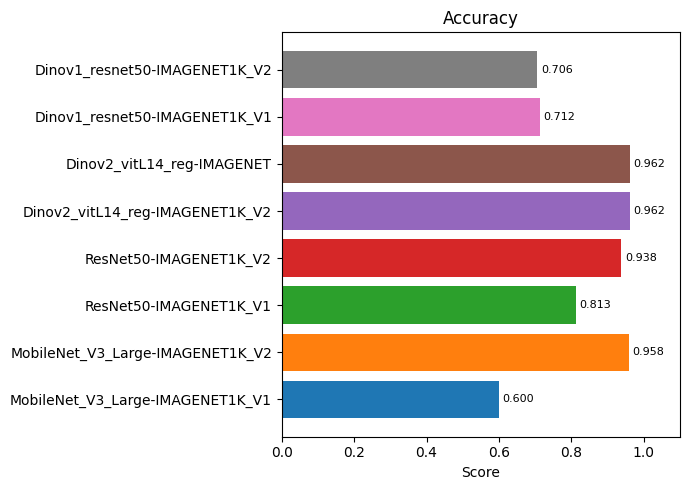

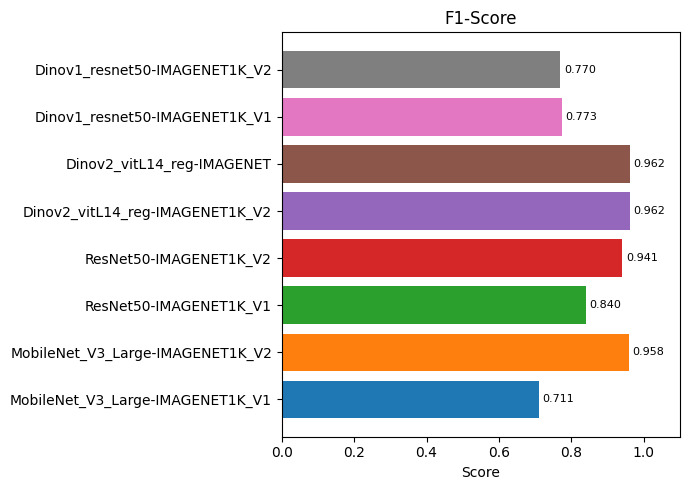

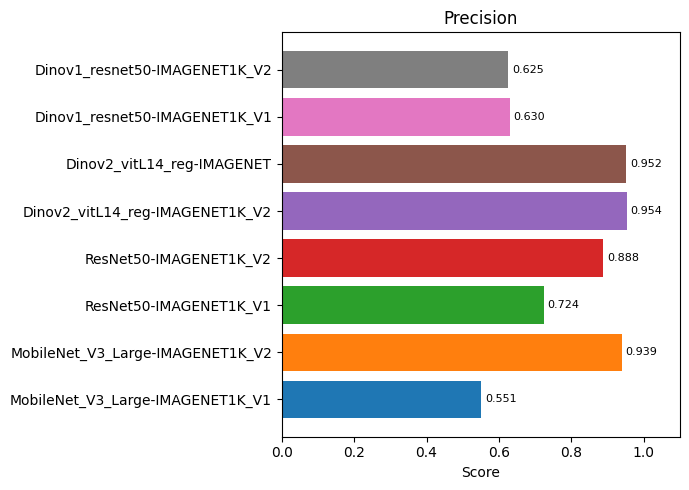

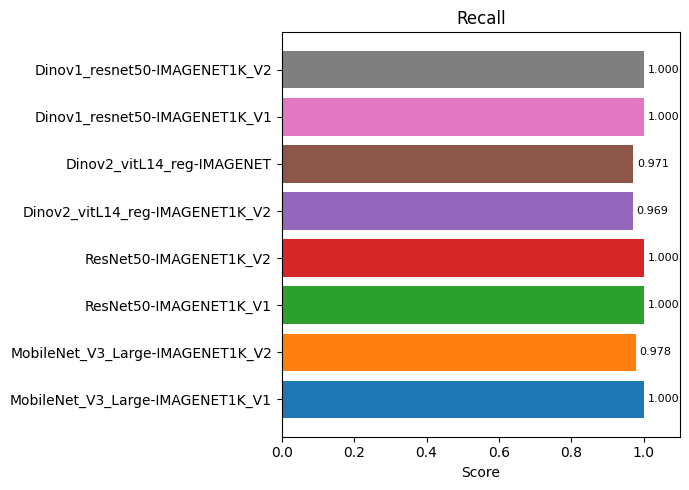

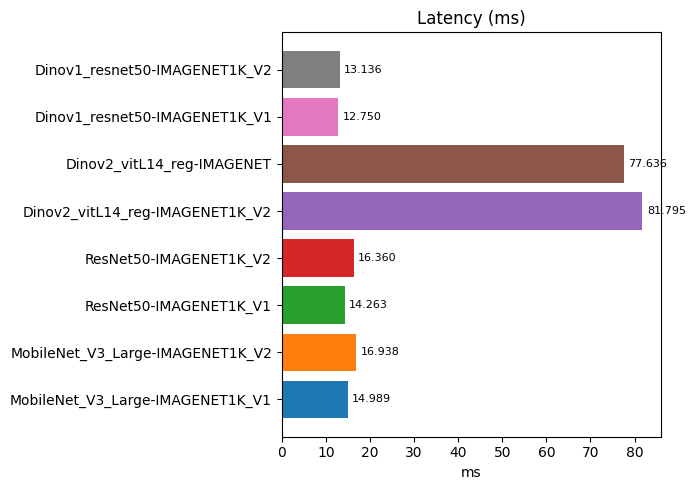

In [19]:
plot_metrics_with_latency(n_metrics, n_models)

In [20]:
import pandas as pd

def export_metrics_to_excel(models_metrics, model_names, filename="metrics_report.xlsx"):
    """
    export metrics (Accuracy, F1, Precision, Recall) ของแต่ละโมเดลไปเป็นไฟล์ Excel
    """
    metrics_names = ["Accuracy", "F1-Score", "Precision", "Recall", "Latency (ms)"]
    df = pd.DataFrame(models_metrics, columns=metrics_names, index=model_names)
    df.to_excel(filename, index=True)
    print(f"✅ Metrics saved to {filename}")


In [21]:
new_metrics = []
for metric in n_metrics:
    metric = list(metric)
    metric[-1] = metric[-1] * 1000
    new_metrics.append(metric)
export_metrics_to_excel(new_metrics, n_models)

✅ Metrics saved to metrics_report.xlsx
